In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# 1 Считайте датасет из файла loan_prediction_dataset.csv (это данные о кредитных заявках) - 1 балл
df = pd.read_csv('/content/loan_prediction_dataset.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
# 2 Выведите таблицу пропусков по каждому столбцу: абсолютное число и % - 1 балл
print(df.isna().sum())
print(df.isna().mean())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Loan_ID              0.000000
Gender               0.021173
Married              0.004886
Dependents           0.024430
Education            0.000000
Self_Employed        0.052117
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.035831
Loan_Amount_Term     0.022801
Credit_History       0.081433
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64


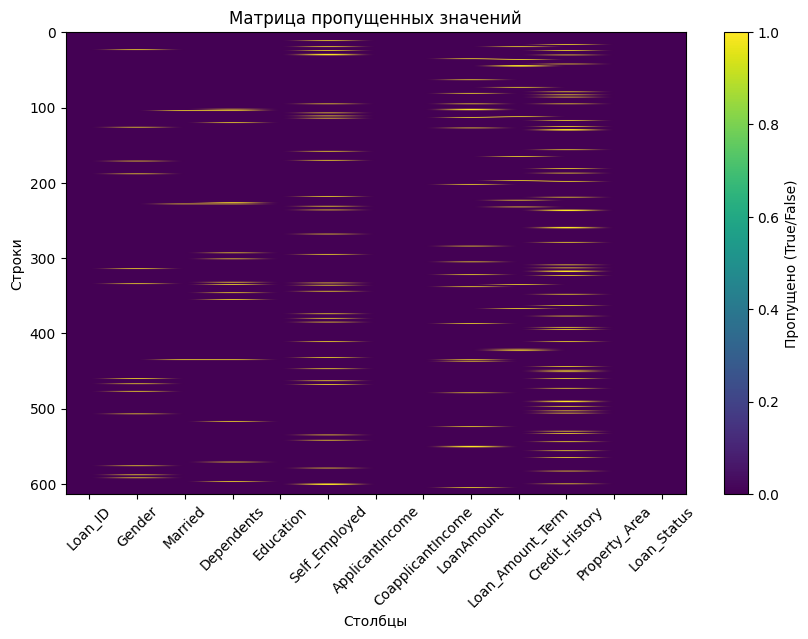

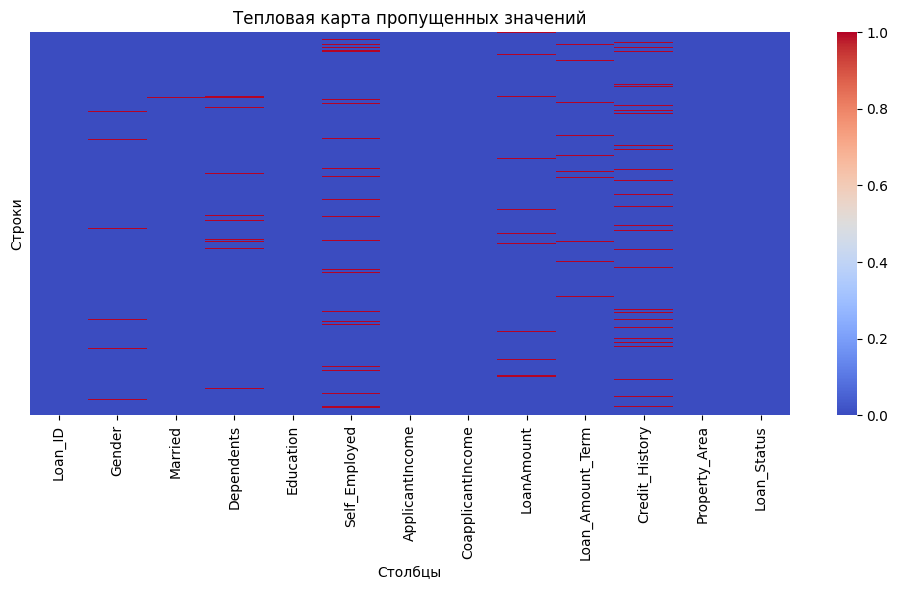


Заметим, что чаще всего пропуски встречаются в столбцах Self_employed и Loan_Amount_Term


In [12]:
# 3 Постройте графики для пропущенных значений: матрицу и тепловую карту - 1 балла


# 1. Матрица пропущенных значений
plt.figure(figsize=(10, 6))
plt.imshow(df.isnull(), cmap='viridis', aspect='auto')
plt.colorbar(label='Пропущено (True/False)')
plt.title('Матрица пропущенных значений')
plt.xlabel('Столбцы')
plt.ylabel('Строки')
plt.xticks(range(len(df.columns)), df.columns, rotation=45)
plt.show()

# 2. Тепловая карта пропущенных значений
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(),
            cbar=True,
            cmap='coolwarm',
            yticklabels=False)  # Убираем подписи строк для читаемости
plt.title('Тепловая карта пропущенных значений')
plt.xlabel('Столбцы')
plt.ylabel('Строки')
plt.tight_layout()
plt.show()

# 4 Проинтепретируйте полученный график - 1 балл
print('')
print('Заметим, что чаще всего пропуски встречаются в столбцах Self_employed и Loan_Amount_Term')

In [15]:
# 5 Разделите данные с пропусками на числовые и категориальные - 1 балл

# 1. Получаем списки столбцов с пропущенными значениями
columns_with_missing = df.columns[df.isnull().any()].tolist()

# 2. Разделяем на числовые и категориальные
numeric_columns_with_missing = df[columns_with_missing].select_dtypes(include=[np.number]).columns.tolist()
categorical_columns_with_missing = df[columns_with_missing].select_dtypes(include=['object', 'category']).columns.tolist()


In [25]:
# 6 Заполните пропуски, обоснуйте выбранные методы - 2 балла
# ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

df_notna = df.copy()
# заполним числовые пропуски медианой этих столбцов, т.к медиана более устойчива к выбросам, чем среднее
df_notna.LoanAmount = df_notna.LoanAmount.fillna(df_notna.LoanAmount.median())
df_notna.Loan_Amount_Term = df_notna.Loan_Amount_Term.fillna(df_notna.Loan_Amount_Term.median())
df_notna.Credit_History = df_notna.Credit_History.fillna(df_notna.Credit_History.median())
# 7 Проверьте, что пропуски заполнились корректно - 1 балл

print('Пропуски заполнились верно:',df_notna.LoanAmount.isna().sum() ==  df_notna.Loan_Amount_Term.isna().sum() == df_notna.Credit_History.isna().sum() == 0)


Пропуски заполнились верно: True


       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count           614.00             614.00      592.00            600.00   
mean           5403.46            1621.25      146.41            342.00   
std            6109.04            2926.25       85.59             65.12   
min             150.00               0.00        9.00             12.00   
25%            2877.50               0.00      100.00            360.00   
50%            3812.50            1188.50      128.00            360.00   
75%            5795.00            2297.25      168.00            360.00   
max           81000.00           41667.00      700.00            480.00   

       Credit_History  
count          564.00  
mean             0.84  
std              0.36  
min              0.00  
25%              1.00  
50%              1.00  
75%              1.00  
max              1.00  


In [33]:
# 8 Покажите статистики до/после заполнения - 1 балл
print('Статистика до заполнения пропусков')
print(df.describe().round(2))

Статистика до заполнения пропусков
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count           614.00             614.00      592.00            600.00   
mean           5403.46            1621.25      146.41            342.00   
std            6109.04            2926.25       85.59             65.12   
min             150.00               0.00        9.00             12.00   
25%            2877.50               0.00      100.00            360.00   
50%            3812.50            1188.50      128.00            360.00   
75%            5795.00            2297.25      168.00            360.00   
max           81000.00           41667.00      700.00            480.00   

       Credit_History  
count          564.00  
mean             0.84  
std              0.36  
min              0.00  
25%              1.00  
50%              1.00  
75%              1.00  
max              1.00  


In [32]:
print('Статистика после заполнения пропусков')
print(df_notna.describe().round(2))

Статистика после заполнения пропусков
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count           614.00             614.00      614.00            614.00   
mean           5403.46            1621.25      145.75            342.41   
std            6109.04            2926.25       84.11             64.43   
min             150.00               0.00        9.00             12.00   
25%            2877.50               0.00      100.25            360.00   
50%            3812.50            1188.50      128.00            360.00   
75%            5795.00            2297.25      164.75            360.00   
max           81000.00           41667.00      700.00            480.00   

       Credit_History  
count          614.00  
mean             0.86  
std              0.35  
min              0.00  
25%              1.00  
50%              1.00  
75%              1.00  
max              1.00  


АНАЛИЗ ВЫБРОСОВ ДЛЯ ApplicantIncome

1. IQR МЕТОД:
   Границы: [-1498.75, 10171.25]
   Количество выбросов: 50
   Процент выбросов: 8.14%

2. STD МЕТОД (3σ):
   Границы: [-12923.67, 23730.58]
   Количество выбросов: 8
   Процент выбросов: 1.30%

АНАЛИЗ ВЫБРОСОВ ДЛЯ LoanAmount

1. IQR МЕТОД:
   Границы: [-2.00, 270.00]
   Количество выбросов: 39
   Процент выбросов: 6.35%

2. STD МЕТОД (3σ):
   Границы: [-110.35, 403.17]
   Количество выбросов: 14
   Процент выбросов: 2.28%


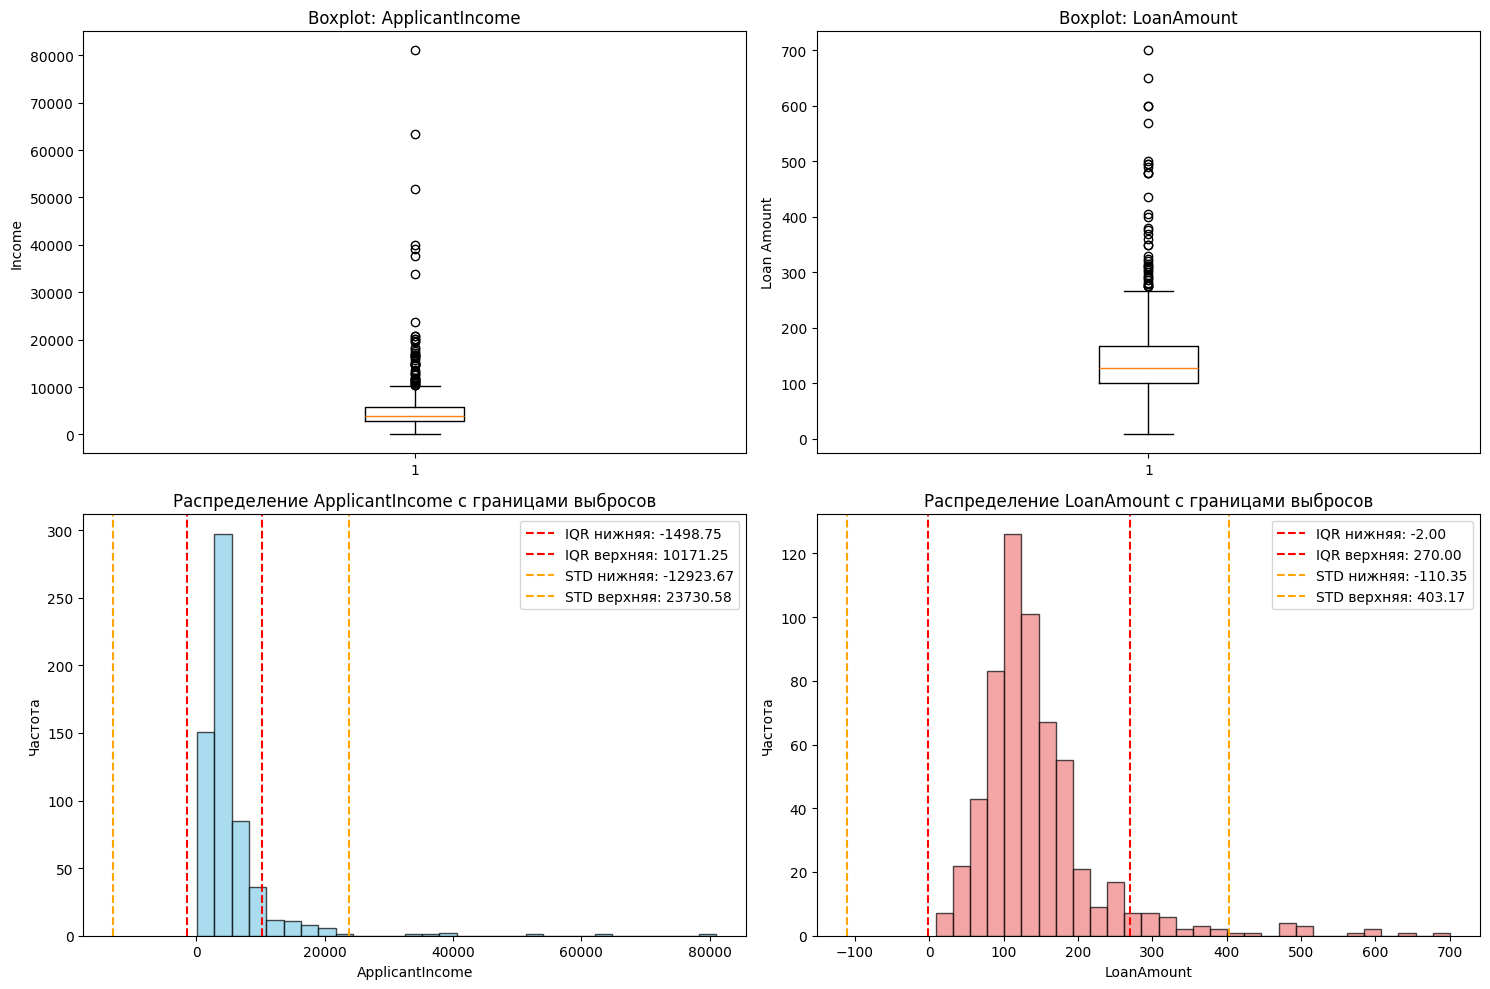


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
  Метод       Переменная  Выбросы Процент
0   IQR  ApplicantIncome       50   8.14%
1   STD  ApplicantIncome        8   1.30%
2   IQR       LoanAmount       39   6.35%
3   STD       LoanAmount       14   2.28%


In [36]:
# 9 Для ApplicantIncome и LoanAmount найдите выбросы двумя способами: IQR-правило и std - 1 балл
# 11 Визуально подтвердите (boxplot/гистограмма) - 2 балла

# Анализ выбросов для ApplicantIncome и LoanAmount
def detect_outliers_iqr(data, column):
    """Обнаружение выбросов с помощью IQR правила"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

def detect_outliers_std(data, column, n_std=3):
    """Обнаружение выбросов с помощью стандартного отклонения"""
    mean = data[column].mean()
    std = data[column].std()
    lower_bound = mean - n_std * std
    upper_bound = mean + n_std * std

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Анализ для ApplicantIncome
print("=" * 60)
print("АНАЛИЗ ВЫБРОСОВ ДЛЯ ApplicantIncome")
print("=" * 60)

# IQR метод
outliers_iqr_income, lower_iqr_income, upper_iqr_income = detect_outliers_iqr(df, 'ApplicantIncome')
print(f"\n1. IQR МЕТОД:")
print(f"   Границы: [{lower_iqr_income:.2f}, {upper_iqr_income:.2f}]")
print(f"   Количество выбросов: {len(outliers_iqr_income)}")
print(f"   Процент выбросов: {(len(outliers_iqr_income) / len(df) * 100):.2f}%")

# STD метод
outliers_std_income, lower_std_income, upper_std_income = detect_outliers_std(df, 'ApplicantIncome')
print(f"\n2. STD МЕТОД (3σ):")
print(f"   Границы: [{lower_std_income:.2f}, {upper_std_income:.2f}]")
print(f"   Количество выбросов: {len(outliers_std_income)}")
print(f"   Процент выбросов: {(len(outliers_std_income) / len(df) * 100):.2f}%")

# Анализ для LoanAmount
print("\n" + "=" * 60)
print("АНАЛИЗ ВЫБРОСОВ ДЛЯ LoanAmount")
print("=" * 60)

# IQR метод
outliers_iqr_loan, lower_iqr_loan, upper_iqr_loan = detect_outliers_iqr(df, 'LoanAmount')
print(f"\n1. IQR МЕТОД:")
print(f"   Границы: [{lower_iqr_loan:.2f}, {upper_iqr_loan:.2f}]")
print(f"   Количество выбросов: {len(outliers_iqr_loan)}")
print(f"   Процент выбросов: {(len(outliers_iqr_loan) / len(df) * 100):.2f}%")

# STD метод
outliers_std_loan, lower_std_loan, upper_std_loan = detect_outliers_std(df, 'LoanAmount')
print(f"\n2. STD МЕТОД (3σ):")
print(f"   Границы: [{lower_std_loan:.2f}, {upper_std_loan:.2f}]")
print(f"   Количество выбросов: {len(outliers_std_loan)}")
print(f"   Процент выбросов: {(len(outliers_std_loan) / len(df) * 100):.2f}%")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Boxplot для ApplicantIncome
axes[0, 0].boxplot(df['ApplicantIncome'].dropna())
axes[0, 0].set_title('Boxplot: ApplicantIncome')
axes[0, 0].set_ylabel('Income')

axes[0, 1].boxplot(df['LoanAmount'].dropna())
axes[0, 1].set_title('Boxplot: LoanAmount')
axes[0, 1].set_ylabel('Loan Amount')

# Гистограммы с отметкой выбросов
axes[1, 0].hist(df['ApplicantIncome'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].axvline(lower_iqr_income, color='red', linestyle='--', label=f'IQR нижняя: {lower_iqr_income:.2f}')
axes[1, 0].axvline(upper_iqr_income, color='red', linestyle='--', label=f'IQR верхняя: {upper_iqr_income:.2f}')
axes[1, 0].axvline(lower_std_income, color='orange', linestyle='--', label=f'STD нижняя: {lower_std_income:.2f}')
axes[1, 0].axvline(upper_std_income, color='orange', linestyle='--', label=f'STD верхняя: {upper_std_income:.2f}')
axes[1, 0].set_title('Распределение ApplicantIncome с границами выбросов')
axes[1, 0].set_xlabel('ApplicantIncome')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()

axes[1, 1].hist(df['LoanAmount'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 1].axvline(lower_iqr_loan, color='red', linestyle='--', label=f'IQR нижняя: {lower_iqr_loan:.2f}')
axes[1, 1].axvline(upper_iqr_loan, color='red', linestyle='--', label=f'IQR верхняя: {upper_iqr_loan:.2f}')
axes[1, 1].axvline(lower_std_loan, color='orange', linestyle='--', label=f'STD нижняя: {lower_std_loan:.2f}')
axes[1, 1].axvline(upper_std_loan, color='orange', linestyle='--', label=f'STD верхняя: {upper_std_loan:.2f}')
axes[1, 1].set_title('Распределение LoanAmount с границами выбросов')
axes[1, 1].set_xlabel('LoanAmount')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Сводная таблица результатов
summary_data = {
    'Метод': ['IQR', 'STD', 'IQR', 'STD'],
    'Переменная': ['ApplicantIncome', 'ApplicantIncome', 'LoanAmount', 'LoanAmount'],
    'Выбросы': [len(outliers_iqr_income), len(outliers_std_income),
                len(outliers_iqr_loan), len(outliers_std_loan)],
    'Процент': [f"{(len(outliers_iqr_income) / len(df) * 100):.2f}%",
                f"{(len(outliers_std_income) / len(df) * 100):.2f}%",
                f"{(len(outliers_iqr_loan) / len(df) * 100):.2f}%",
                f"{(len(outliers_std_loan) / len(df) * 100):.2f}%"]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 50)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 50)
print(summary_df)

In [58]:
# 12 Выберете метод заполнения пропусков, примените его к данным - 1 балл
# ['Gender', 'Married', 'Dependents', 'Self_Employed']

# заменим пропуски категориальных переменных их модами
df_notna.Gender = df_notna.Gender.fillna(df_notna.Gender.value_counts().reset_index().iloc[0][0])
df_notna.Married = df_notna.Married.fillna(df_notna.Married.value_counts().reset_index().iloc[0][0])
df_notna.Dependents = df_notna.Dependents.fillna(df_notna.Dependents.value_counts().reset_index().iloc[0][0])
df_notna.Self_Employed = df_notna.Self_Employed.fillna(df_notna.Self_Employed.value_counts().reset_index().iloc[0][0])


In [68]:
# 13 Предложите варианты кодирования категориальных переменных, обоснуйте - 2 балла
# 14 Примените выбранные правила перекодирования переменных - 2 балла
# 15 Проверьте результат - 1 балл

# заменим Male на 1, а Female на 0
df_notna.Gender = np.where(df_notna.Gender == 'Male', 1,0)

# заменим Yes на 1, а No на 0
df_notna.Married = np.where(df_notna.Married == 'Yes', 1,0)

# заменим 0 на A, 1 на В, 2 на С, 3+ на D
df_notna.Dependents = df_notna.Dependents.str.replace('0','A').str.replace('1','B').str.replace('2','C').str.replace('3+','D')

# заменим Yes на 1, а No на 0
df_notna.Self_Employed = np.where(df_notna.Self_Employed == 'Yes', 1,0)

df_notna

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0,0,A,Graduate,0,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,0,0,B,Graduate,0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,0,0,A,Graduate,0,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,0,0,A,Not Graduate,0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,0,0,A,Graduate,0,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,A,Graduate,0,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,0,0,D,Graduate,0,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,0,0,B,Graduate,0,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,0,0,C,Graduate,0,7583,0.0,187.0,360.0,1.0,Urban,Y
